In [2]:
!pip install snowflake-connector-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found ex

In [1]:
import pandas as pd
import numpy as np

In [3]:
import snowflake.connector

In [6]:
from google.colab import userdata
import snowflake.connector

conn = snowflake.connector.connect(
    user=userdata.get('SNOWFLAKE_USER'),
    password=userdata.get('SNOWFLAKE_PASSWORD'),
    account=userdata.get('SNOWFLAKE_ACCOUNT'),
    warehouse=userdata.get('SNOWFLAKE_WAREHOUSE'),
    database=userdata.get('SNOWFLAKE_DATABASE'),
    schema=userdata.get('SNOWFLAKE_SCHEMA')
)

In [7]:
query='SELECT * FROM "OBESITY"'
df=pd.read_sql(query,conn)

/tmp/ipykernel_1168/4182751305.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


In [8]:
conn.close()

In [9]:
print(df.head())

   ID  AGE  GENDER  HEIGHT  WEIGHT   BMI          LABEL
0   1   25    Male     175      80  25.3  Normal Weight
1   2   30  Female     160      60  22.5  Normal Weight
2   3   35    Male     180      90  27.3     Overweight
3   4   40  Female     150      50  20.0    Underweight
4   5   45    Male     190     100  31.2          Obese


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      108 non-null    int64  
 1   AGE     108 non-null    int64  
 2   GENDER  108 non-null    object 
 3   HEIGHT  108 non-null    int64  
 4   WEIGHT  108 non-null    int64  
 5   BMI     108 non-null    float64
 6   LABEL   108 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 6.0+ KB


In [11]:
df.shape

(108, 7)

In [12]:
df.describe()

,ID,AGE,HEIGHT,WEIGHT,BMI
count,108.000000,108.000000,108.000000,108.000000,108.000000
mean,56.046296,46.555556,166.574074,59.490741,20.549074
std,31.917939,24.720620,27.873615,28.856233,7.583818
min,1.000000,11.000000,120.000000,10.000000,3.900000
25%,28.750000,27.000000,140.000000,35.000000,16.700000
50%,56.500000,42.500000,175.000000,55.000000,21.200000
75%,83.250000,59.250000,190.000000,85.000000,26.100000
max,110.000000,112.000000,210.000000,120.000000,37.200000


In [13]:
df.isnull().sum()

,0
ID,0
AGE,0
GENDER,0
HEIGHT,0
WEIGHT,0
BMI,0
LABEL,0


In [14]:
from scipy.stats import zscore
z_scores=zscore(df['AGE'])
df[np.abs(z_scores)>2.2]

,ID,AGE,GENDER,HEIGHT,WEIGHT,BMI,LABEL
27,29,103,Female,130,30,13.3,Underweight
28,30,108,Male,210,120,37.2,Obese
55,58,102,Female,130,75,25.0,Overweight
56,59,107,Male,210,105,28.9,Obese
57,60,112,Female,120,85,27.5,Overweight


In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['GENDER']=le.fit_transform(df['GENDER'])

In [16]:
X = df.iloc[:,:-1]
y = df['LABEL'].values

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='entropy',max_depth=4)
dt.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [19]:
y_pred = dt.predict(X_test)
y_pred

array(['Normal Weight', 'Normal Weight', 'Obese', 'Underweight',
       'Normal Weight', 'Overweight', 'Normal Weight', 'Overweight',
       'Underweight', 'Underweight', 'Underweight', 'Underweight',
       'Overweight', 'Underweight', 'Obese', 'Underweight', 'Obese',
       'Overweight', 'Underweight', 'Overweight', 'Overweight', 'Obese'],
      dtype=object)

In [20]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
ac=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(cr)

               precision    recall  f1-score   support

Normal Weight       1.00      0.67      0.80         6
        Obese       1.00      1.00      1.00         4
   Overweight       0.67      1.00      0.80         4
  Underweight       1.00      1.00      1.00         8

     accuracy                           0.91        22
    macro avg       0.92      0.92      0.90        22
 weighted avg       0.94      0.91      0.91        22



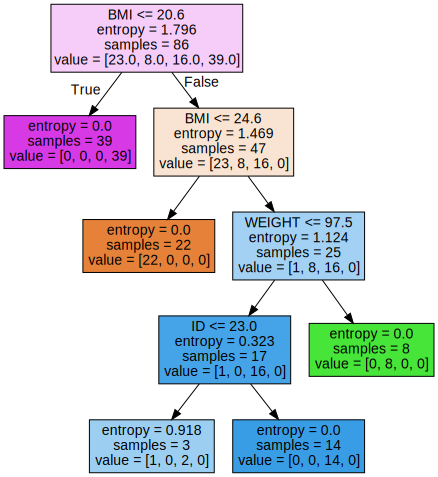

In [21]:
from sklearn.tree import export_graphviz
import graphviz
graphviz.Source(export_graphviz(dt,feature_names=X.columns,filled=True))